### Import libraries

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

import matplotlib as mpl
mpl.rcParams["font.family"] = "Nimbus Roman"
from matplotlib.collections import LineCollection


import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))

from ml_force.models import MorrisLecar, MorrisLecarCurrent
from ml_force.utils import z_transform

In [55]:
save_dir = os.path.join(os.getcwd(), "img/mlc")

In [3]:
T = 10000
dt = 5e-2
t = np.arange(0, T, dt)

### Run Models

#### Preparing functions

In [7]:
from ml_force.supervisors import VanDerPol, LorenzAttractor

# x = VanDerPol(T, dt, mu=.5, tau=0.015).generate(transient_time=200)
x = LorenzAttractor(T, dt, tau=0.01).generate(transient_time=500)
x = x.T
# x = np.sin(2 * 10 * np.pi * t / 1000)
# x = x.reshape(-1, 1)

x = z_transform(x)
print(x.shape)

(200000, 3)


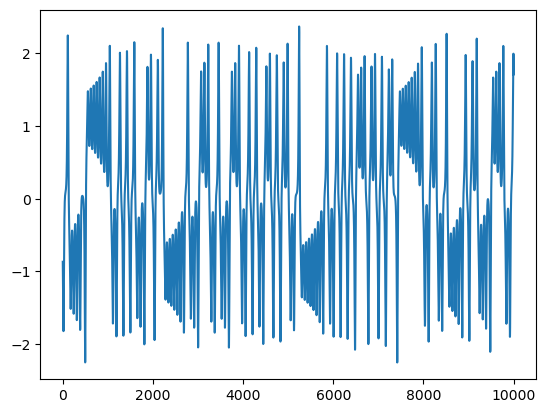

In [8]:
plt.plot(t, x[:, 0])
plt.show()

#### Run Current-Based Model model

In [9]:
## TORCH SETUP
seed = 1
np.random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

Using Device <cuda> for PyTorch computations...



In [ ]:
Ne = 400
Ni = 100
# N = Ne + Ni

# input current for I and E neurons
Ie = 60
Ii = 60
current = np.array([Ie] * Ne + [Ii] * Ni).reshape(-1, 1)
p = .1
gbar = 50
Q = 0

# x = np.zeros(shape=x.shape, dtype=float)
ml = MorrisLecarCurrent(supervisor=x, T=T, dt=dt, Ne=Ne, Ni=Ni, 
                        BIAS=current, gbar=gbar, Q=Q, l=1.0, 
                        device=device, p_sparsity=p)

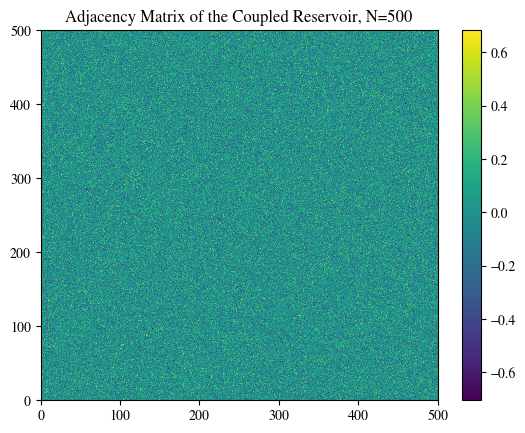

In [81]:
clr = plt.pcolormesh(ml.w.cpu().numpy(), cmap="viridis")
plt.colorbar(clr)
plt.title(f"Adjacency Matrix of the Coupled Reservoir, N={ml._N}")
# plt.savefig("img/weight_matrix.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [82]:
print("mean abs:", ml.w.abs().mean().item())
print("std:", ml.w.std().item())
print("mean:", ml.w.mean().item())
print("min", ml.w.min().item())
print("max:", ml.w.max().item())

mean abs: 0.11292171478271484
std: 0.14141786098480225
mean: -7.973713945830241e-05
min -0.7031795382499695
max: 0.6830613017082214


In [83]:
rls_start = 500
rls_stop = -1
rls_step = 20

render_params = {"rls_start": rls_start,
                    "rls_stop": rls_stop,
                    "rls_step": rls_step,
                    "live_plot": False,
                    "n_neurons": 10,
                    "plt_interval": 300,
                    "save_all": True}

_, voltage_trace, decoder_trace = ml.render(**render_params)

100%|██████████| 200000/200000 [01:05<00:00, 3056.22it/s]


In [70]:
def plot_voltage_trace(voltage_trace_np:np.ndarray, rands:np.ndarray, t, step:int=1, shift:int=0, save_dir:str="img", extension:str="png"):
    """
    Plot the voltage trace of the neurons in the reservoir.
    """
    fig, ax = plt.subplots(figsize=(15, 8), ncols=2)
    # Ax 0
    for i, num in enumerate(rands):
        signal = voltage_trace_np[::step, num]
        minim = np.nanmin(signal)
        maxim = np.nanmax(signal)
        signal = (signal - minim) / (maxim - minim) + i+1
        ax[0].plot(t[::step], signal, lw=1)
    ax[0].grid(alpha=.5)
    ax[0].set_xlabel("Time [ms]")
    ax[0].set_ylabel("Voltage Trace (normalized)")
    # Ax 1
    midpoint = ml._N // 2
    e_ind = shift
    i_ind = midpoint + shift
    # e_ind = 1
    # i_ind = 3
    start = 0
    ve_store = voltage_trace_np[start::step, e_ind]
    vi_store = voltage_trace_np[start::step, i_ind]
    points = np.array([ve_store, vi_store]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = mpl.colors.Normalize(vmin=t.min(), vmax=t.max())
    lc = LineCollection(segments, norm=norm, cmap='bwr', linewidth=1)
    lc.set_array(t[start::step])
    ax[1].add_collection(lc)
    ax[1].autoscale()
    ax[1].grid(alpha=.5)
    ax[1].set_xlabel(f"neuron {e_ind}")
    ax[1].set_ylabel(f"neuron {i_ind}")
    cbar = plt.colorbar(lc)
    cbar.set_label('Time [ms]')

    plt.suptitle(f"N = {ml._N}, Ie = {Ie}, Ii = {Ii}", fontsize=20)
    try:
        plt.savefig(os.path.join(save_dir, "initial_chaos_voltage_trace." + extension), dpi=300, bbox_inches='tight')
    except FileNotFoundError:
        print(f"Creating directory {save_dir}...")
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, "initial_chaos_voltage_trace." + extension), dpi=300, bbox_inches='tight')
    plt.show()

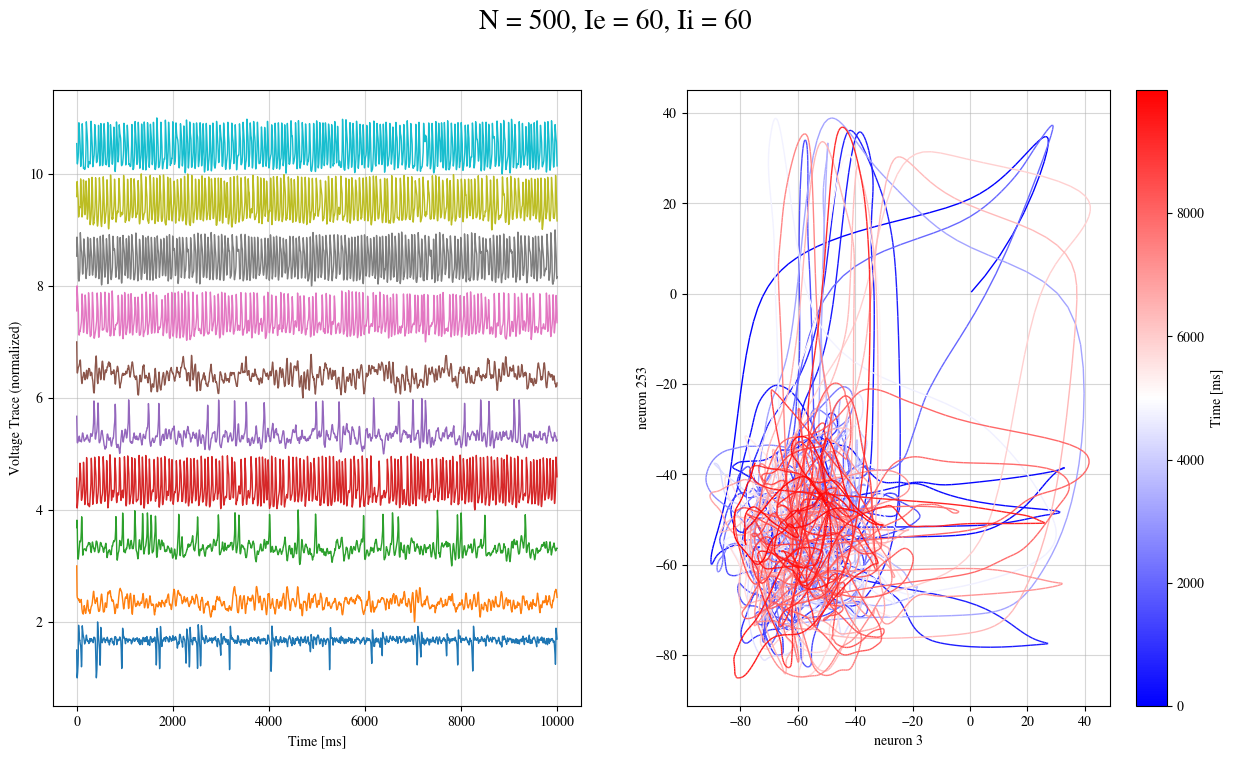

In [90]:

voltage_trace_np = voltage_trace.numpy()
rands = np.random.randint(low=0, high=ml._N, size=10)

step = 10
shift = 3
plot_voltage_trace(voltage_trace_np, rands, t, step=step, shift=shift, save_dir=save_dir)

(20000,)


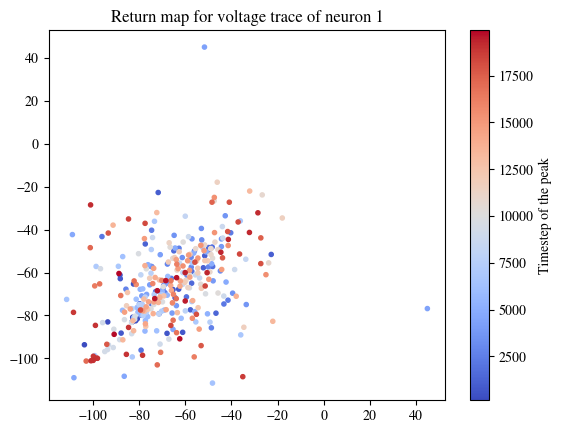

In [76]:
from scipy.signal import find_peaks


# Return Map
signal = ve_store
print(signal.shape)
# signal = z_transform(signal)
peaks = find_peaks(signal)[0]

clr = plt.scatter(signal[peaks[:-1]], signal[peaks[1:]], c=peaks[1:], cmap="coolwarm", marker='.')
plt.colorbar(clr, label="Timestep of the peak")
plt.title(f"Return map for voltage trace of neuron {e_ind}")
# plt.savefig("img/initial_chaos_return_map_exc.jpg", dpi=300, bbox_inches="tight")
plt.show()
